# Images and Tensors in CNN

CNN works with images, but a computer does not understand an image like humans do.

A computer represents an image as a collection of numerical values called **pixels**.

These pixel values are stored in the form of tensors.

So the basic relationship is:

Image → Pixels → Tensor → CNN

# What is a Pixel?

A pixel is the smallest unit of a digital image.

Each pixel contains numerical information representing the color or intensity at that location.

For a grayscale image, a pixel usually has a value between:

0 → Black
255 → White

Example:

0, 50, 128, 200, 255

For RGB images, every pixel contains three values:

R → Red
G → Green
B → Blue

In [8]:
import numpy as np

pixel = 128

print("Pixel value:", pixel)
print("Data type:", type(pixel))

Pixel value: 128
Data type: <class 'int'>


# Grayscale Image

A grayscale image contains only one channel.

The shape is usually:

Height × Width

For example:

28 × 28

This means:

28 pixels in height
28 pixels in width

Total pixels:

28 × 28 = 784

In [9]:
import numpy as np

gray_image = np.random.randint(
    0,
    256,
    size=(28, 28),
    dtype=np.uint8
)

print("Shape:", gray_image.shape)
print("Minimum pixel value:", gray_image.min())
print("Maximum pixel value:", gray_image.max())

Shape: (28, 28)
Minimum pixel value: 0
Maximum pixel value: 255


# Visualizing a Grayscale Image

Matplotlib can display a grayscale image using `cmap="gray"`.

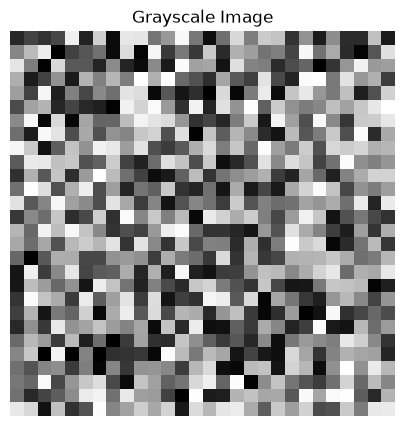

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))

plt.imshow(gray_image, cmap="gray")
plt.axis("off")
plt.title("Grayscale Image")

plt.show()

# RGB Image

RGB stands for:

R → Red
G → Green
B → Blue

Each pixel contains three values.

For example:

Pixel = [255, 0, 0]

means strong red.

Another example:

Pixel = [0, 255, 0]

means green.

Another:

Pixel = [0, 0, 255]

means blue.

In [11]:
red_pixel = np.array([255, 0, 0])
green_pixel = np.array([0, 255, 0])
blue_pixel = np.array([0, 0, 255])

print("Red pixel:", red_pixel)
print("Green pixel:", green_pixel)
print("Blue pixel:", blue_pixel)

Red pixel: [255   0   0]
Green pixel: [  0 255   0]
Blue pixel: [  0   0 255]


# RGB Image Shape

An RGB image has three dimensions:

Height × Width × Channels

For example:

64 × 64 × 3

Where:

64 = Height
64 = Width
3 = RGB channels

Therefore, an RGB image with shape `(64, 64, 3)` contains:

64 × 64 × 3 = 12,288 values.

In [12]:
rgb_image = np.random.randint(
    0,
    256,
    size=(64, 64, 3),
    dtype=np.uint8
)

print("RGB image shape:", rgb_image.shape)
print("Total values:", rgb_image.size)

RGB image shape: (64, 64, 3)
Total values: 12288


# Visualizing an RGB Image

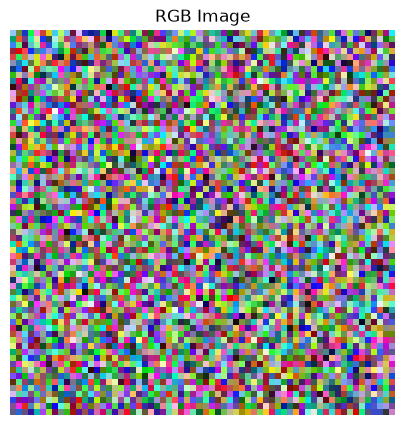

In [13]:
plt.figure(figsize=(5, 5))

plt.imshow(rgb_image)
plt.axis("off")
plt.title("RGB Image")

plt.show()

# What is a Tensor?

A tensor is a multi-dimensional numerical data structure.

In Deep Learning, tensors are used to represent:

- Images
- Text
- Audio
- Video
- Model weights
- Predictions
- Batches of data

You can think of a tensor as an extension of:

Scalar → Vector → Matrix → Higher-dimensional Tensor

# Tensor Dimensions

## Scalar

A single number:

5

Shape:

()

## Vector

A one-dimensional collection:

[1, 2, 3]

Shape:

(3,)

## Matrix

A two-dimensional collection:

[[1, 2],
 [3, 4]]

Shape:

(2, 2)

## 3D Tensor

For example:

Height × Width × Channels

(64, 64, 3)

In [14]:
import tensorflow as tf

scalar = tf.constant(5)

vector = tf.constant([1, 2, 3])

matrix = tf.constant([
    [1, 2],
    [3, 4]
])

tensor_3d = tf.random.uniform(
    shape=(64, 64, 3)
)

print("Scalar shape:", scalar.shape)
print("Vector shape:", vector.shape)
print("Matrix shape:", matrix.shape)
print("3D tensor shape:", tensor_3d.shape)

Scalar shape: ()
Vector shape: (3,)
Matrix shape: (2, 2)
3D tensor shape: (64, 64, 3)


# Image as a Tensor

When we convert an image into a tensor, its pixels become numerical tensor values.

For an RGB image:

64 × 64 × 3

means:

Height = 64
Width = 64
Channels = 3

So:

Image → Tensor

In [15]:
image_tensor = tf.convert_to_tensor(rgb_image)

print("Tensor:")
print(image_tensor)

print("\nShape:", image_tensor.shape)
print("Rank:", len(image_tensor.shape))
print("Data type:", image_tensor.dtype)

Tensor:
tf.Tensor(
[[[149 198 247]
  [113 138  56]
  [ 27  54 195]
  ...
  [148 170   6]
  [172  14 127]
  [ 23 237 253]]

 [[  0 163 105]
  [234  92  31]
  [118  58 139]
  ...
  [223 203 223]
  [  8 121  14]
  [ 75 195  77]]

 [[ 58 129 250]
  [103 240 119]
  [ 86   5  73]
  ...
  [142 103 250]
  [193  94 117]
  [ 92  17  97]]

 ...

 [[ 44  68 229]
  [139  10 142]
  [122   3 202]
  ...
  [ 34 181 213]
  [151 162  39]
  [  8  98 140]]

 [[133  78 149]
  [242  40 228]
  [228  42  18]
  ...
  [118 158 238]
  [168 150 226]
  [121  74 153]]

 [[ 94  89 139]
  [ 45 102 202]
  [101  78 131]
  ...
  [ 58  76 186]
  [ 46  54  56]
  [203 127 197]]], shape=(64, 64, 3), dtype=uint8)

Shape: (64, 64, 3)
Rank: 3
Data type: <dtype: 'uint8'>


# Image Tensor Data Type

Images are often loaded as `uint8`.

The range is:

0 → 255

However, neural networks commonly work better when image values are converted to floating-point numbers and normalized.

A common normalization is:

pixel / 255

This converts:

0 → 0.0
255 → 1.0

In [16]:
image_float = tf.cast(image_tensor, tf.float32)

normalized_image = image_float / 255.0

print("Original dtype:", image_tensor.dtype)
print("New dtype:", normalized_image.dtype)

print("Minimum:", tf.reduce_min(normalized_image).numpy())
print("Maximum:", tf.reduce_max(normalized_image).numpy())

Original dtype: <dtype: 'uint8'>
New dtype: <dtype: 'float32'>
Minimum: 0.0
Maximum: 1.0
